# ArcFace Loss (Additive Angular Margin Loss)

## Теория ArcFace

В случае с обучением на задачу классификации первая подходящая лосс-функция, которая нам приходит в голову — Cross-Entropy. И на ней действительно можно обучать сеть для распознавания лиц. Но за много лет люди придумали более хитрые трюки, которые делают обучение сети для распознавания лиц более эффективным. Одним из лучших подходов считается ArcFace (Additive Angular Margin).


**Как устроен ArcFace**:

Стандартные SoftMax + кросс-энтропия (CE) выглядят так:

$$L_{CE} = \frac{-1}{N}\sum_1^N \frac{e^{W_{y_i}^{T}x_i + b_{y_i}}}{\sum^n_{j=1}e^{W_j^Tx_i+b_j}},$$

здесь:
- $x_i \in \mathbb{R^d}$ — вектор $i$-го элемента обучающей выборки перед последним полносвязным слоем сети. $y_i$ — класс этого элемента;
- $W_j \in \mathbb{R^d}$ — j-ый столбец матрицы весов последнего слоя сети (т.е. слоя, который производит итоговую классификацю входящего объекта);
- $b_j \in \mathbb{R^d}$ — j-ый элемент вектора байеса последнего слоя сети;
- $N$ — batch size;
- $n$ — количество классов.


Хотя этот лосс работает хорошо, он явным образом не заставляет эмбеддинги $x_i$ элементов, принадлежащих одному классу, быть близкими друг к другу по расстоянию. И не заставляет эмбеддинги элементов, принадлежащих разным классам, быть далеко друг от друга. Все, что хочет этот лосс — чтобы на основе эмбеддингов $x_i$ можно было хорошо классифицировать элементы, никакие ограничений на расстояния между эмбеддингами $x_i$ он не вводит.

Из-за этого у нейросетей для распознавания лиц, которые обучены на обычном CE loss, бывают проблемы с распознаванием лиц, которые сильно отличаются от лиц того же человека разными доп. атрибутами (шляпа/прическа/очки и т.п.). Просто эмбеддинг для таких лиц получается довольно далек по расстоянию от других эмбеддингов лиц этого же человека.

Давайте теперь немного поправим формулу:
- уберем байес последнего слоя, т.е. сделаем $b_j=0$;
- нормализуем веса последнего слоя: ||$W_j$|| = 1;
- нормализуем эмбеддинги: ||$x_i$|| = 1. Перед подачей их на вход последнему слою (т.е. перед умножением на матрицу $W_j$) умножим их на гиперпараметр s. По сути, мы приводим норму всех эмбеддингов к s. Смысл этого гиперпараметра в том, что, возможно, сети проще будет классифицировать эмбеддинги, у которых не единичная норма.

Нормализация приводит к тому, что эмбеддинги распределяются по сфере единичного радиуса (и сфере радиуса s после умножения на гиперпараметр s). И итоговые предсказания сети после последнего слоя зависят только от угла между эмбеддингами $x_i$ и выученных весов $W_j$. От нормы эмбеддинга $x_i$ они больше не зависят, т.к. у всех эмбеддингов они теперь одинаковые.

Получается, в степени экспоненты у нас останется выражение $s W_{y_i}^{T}x_i$, которое можно переписать в виде  $s W_{y_i}^{T}x_i = s ||W_{y_i}||\cdot ||x_i|| \cdot cos\Theta_{y_i}$. Тут $\Theta_{y_i}$ — это угол между векторами $W_{y_i}$ и $x_i$. Но так как мы сделали нормы $W_{y_i}$ и $x_i$ единичными, то все это выражение просто будет равно $s cos\Theta_{y_i}$.

В итоге мы получим следующую формулу лосса:

$$L = \frac{-1}{N}\sum_1^N \frac{e^{s\ cos\Theta_{y_i}}}{e^{s\ cos\Theta_{y_i}} + \sum^n_{j=1,\ j\ne y_i} e^{s\ cos\Theta_j}}$$


И последний шаг. Добавим еще один гиперпараметр $m$. Он называется additive angular margin penalty и заставляет эмбеддинги одного класса быть ближе друг к другу, а эмбеддинги разных классов — более далекими друг от друга.

В итоге получим вот что:

$$L_{ArcFace} = \frac{-1}{N}\sum_1^N \frac{e^{s\ cos(\Theta_{y_i} + m)}}{e^{s\ cos(\Theta_{y_i} + m)} + \sum^n_{j=1,\ j\ne y_i} e^{s\ cos\Theta_j}}$$

Это и есть ArcFace Loss с двумя  гиперпараметрами, s и m.

Получается, что ArcFace Loss заставляет сеть выучивать эмбеддинги, распределенные по сфере радиуса s, причем чтобы эмбеддинги одного класса были ближе друг к другу, а эмбеддинги разных классов — более далеки друг от друга.

![ArcFace](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTKRR-YA_XR3yhIYBbkc8Zlbua0Q2WdM3gx_g&s)

**Важное пояснение:**

Строго говоря, ArcFace - не лосс, отдельный архитектурный модуль модификация SoftMax. Он реализует идею внесения геометрического отступа непосредственно в пространство признаков. Для обучения в качестве лосса используется обычная кросс-энтропия. Более конкретно по шагам:

1. Вы извлекаете эмбеддинги из бэкбона сети (предобученной модели, у которой обрезан FC-слой, если он был)
2. Эти эмбеддинги поступают в ArcFace-слой, который содержит векторы-центры для каждого класса (веса классификатора) и логику нормализации и добавления углового отступа
3. Для целевого класса ArcFace-слой преобразует косинус угла $\theta$ в $cos(\theta + m)$
4. Для остальных классов оставляет обычный косинус $cos(\theta)$
5. Эти модифицированные логиты подаются на вход стандартной функции Cross-Entropy
6. Градиенты от Cross-Entropy текут назад через ArcFace-слой к бэкбону, обучая модель извлекать эмбеддинги

Результат: модифицированные логиты с "жестким" разделением для целевого класса, а значит и более качественные эмбеддинги.

Схема:
```
[Изображение] → [Бэкбон] → [ЭМБЕДДИНГ] → [ArcFace] → [Логиты] → [CE Loss]
                    │                        │           │          
                   CNN                   Нормализация   Оценки
                                          + Angular    для всех
                                            Margin     классов
```

Для получения качественных эмбеддингов после обучения ArcFace-слой больше не нужен, и его обычно обрезают. Он нужен был только обучения модели, и поэтому часто ArcFace называю именно лоссом. Но стоит всегда держать в голове, что это некоторое упрощение, которое нужно лишь для того, чтобы проще формулировать мысли.

**Доп. литература по ArcFace Loss:**

Оригинальная статья: https://arxiv.org/pdf/1801.07698.pdf

## Другие лоссы

Кроме ArcFace, есть еще много разных вариантов лоссов для задачи Face Recognition. Некоторые из них можно найти, например, [тут](https://openaccess.thecvf.com/content_CVPRW_2020/papers/w48/Hsu_A_Comprehensive_Study_on_Loss_Functions_for_Cross-Factor_Face_Recognition_CVPRW_2020_paper.pdf). Вы можете попробовать реализовать другие лосс-функции в этом проекте в качестве дополнительного задания.

Кроме этого, можно миксовать лосс-функции. Например, обучать нейросеть на сумме ArcFace и TripletLoss. Иногда так выходит лучше, чем если обучать на каком-то одном лоссе.

# Датасет

В качестве датасета нужно использовать картинки из CelebA, выровненные при помощи своей модели из задания 1. Очень желательно их еще кропнуть таким образом, чтобы нейросети поступали на вход преимущественно только лица без какого либо фона, частей тела и прочего.

Если планируете делать дополнительное задание на Identificaton rate metric, то **обязательно разбейте заранее датасет на train/val или train/val/test.** Это нужно сделать не только на уровне кода, а на уровне папок, чтобы точно знать, на каких картинках модель обучалась, а на каких нет. Лучше заранее почитайте [ноутбук с заданием](https://colab.research.google.com/drive/15zuNdOupRFnG7oE-rFj9FsjoNTK6DYn5).

# План заданий

Итак, вот, что от вас требуется в этом задании:

* Выбрать модель (или несколько моделей) для обучения. Можно брать предобученные на ImageNet, но нельзя использовать модели, предобученные на задачу распознавания лиц.
* Обучить эту модель (модели) на CE loss. Добиться accuracy > 0.7.
* Реализовать ArcFace loss.
* Обучить модель (модели) на ArcFace loss. Добиться accuracy > 0.7.
* Написать небольшой отчет по обучению, сравнить CE loss и ArcFace loss.

**P.S. Не забывайте сохранять модели после обучения**

## Импорты

In [ ]:
from google.colab import drive

import os

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.models as models
import torchvision.transforms as T

from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil

from tqdm import tqdm
import matplotlib.pyplot as plt


## Загрузка датасета

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Пути
DATA_PATH = '/content/drive/MyDrive/DLS1'
IDENTITY_FILE = os.path.join(DATA_PATH, 'person_id_aligned.csv')
IMAGES_DIR = os.path.join(DATA_PATH, 'aligned_images')

# Локальные папки для обработки
RAW_DIR = '/content/dataset/raw'          # Копии изображений
TRAIN_DIR = '/content/dataset/train'
VAL_DIR = '/content/dataset/val'

# Создаём папки
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

In [ ]:
# Читаем файл
df = pd.read_csv(IDENTITY_FILE)

# Если первая колонка действительно не нужна, убираем её
if 'Unnamed: 0.1' in df.columns:
    df = df.drop(columns=['Unnamed: 0.1'])

# Проверяем оставшиеся колонки
# print("Колонки в df:", df.columns.tolist())
df.head()

,Unnamed: 0,image_id,person_id
0,0,000001.jpg,2880
1,14,000015.jpg,1854
2,15,000016.jpg,4905
3,17,000018.jpg,2464
4,33,000034.jpg,1603


Здесь ниже закомментирвоаны две ячейки, которые были созданы для технической проверки полного копирования. При необходимости можно их раскомментировать и качать не архив,а полную папку, но сейчас в этом нет необходимости, тк архив полноценный.

In [ ]:
#source_folder = '/content/drive/MyDrive/DLS1/aligned_images'

# Получаем список имён файлов из папки
#file_names = set(os.listdir(source_folder))
#print(f"Количество файлов в папке '{source_folder}': {len(file_names)}")

#print(f"Исходное количество строк в датасете: {len(df)}")

# Фильтруем датасет: оставляем только строки, где img_id есть в списке файлов папки
#df = df[df['image_id'].isin(file_names)].reset_index(drop=True)

# Выводим результаты
#print(f"Количество строк в отфильтрованном датасете: {len(df)}")

# Дополнительная проверка: есть ли файлы из датасета, которых нет в папке?
#missing_in_folder = set(df['image_id']) - file_names
#if missing_in_folder:
    #print(f"\nВнимание: в датасете есть {len(missing_in_folder)} img_id, отсутствующих в папке:")
    # Печатаем первые 10, чтобы не загромождать вывод
    #print(list(missing_in_folder)[:10])
#else:
    #print("\nВсе img_id из датасета присутствуют в папке.")

'\nsource_folder = \'/content/drive/MyDrive/DLS1/aligned_images\'\n\n# Получаем список имён файлов из папки\nfile_names = set(os.listdir(source_folder))\nprint(f"Количество файлов в папке \'{source_folder}\': {len(file_names)}")\n\nprint(f"Исходное количество строк в датасете: {len(df)}")\n\n# Фильтруем датасет: оставляем только строки, где img_id есть в списке файлов папки\ndf = df[df[\'image_id\'].isin(file_names)].reset_index(drop=True)\n\n# Выводим результаты\nprint(f"Количество строк в отфильтрованном датасете: {len(df)}")\n\n# Дополнительная проверка: есть ли файлы из датасета, которых нет в папке?\nmissing_in_folder = set(df[\'image_id\']) - file_names\nif missing_in_folder:\n    print(f"\nВнимание: в датасете есть {len(missing_in_folder)} img_id, отсутствующих в папке:")\n    # Печатаем первые 10, чтобы не загромождать вывод\n    print(list(missing_in_folder)[:10])\nelse:\n    print("\nВсе img_id из датасета присутствуют в папке.")\n'

In [ ]:
#def copy_with_count(src, dst):
    #count = 0
    #for root, _, files in os.walk(src):
        #for f in files:
            #src_file = os.path.join(root, f)
            #dst_file = os.path.join(dst, os.path.relpath(src_file, src))
            #os.makedirs(os.path.dirname(dst_file), exist_ok=True)
            #shutil.copy2(src_file, dst_file)
            #count += 1
            #print(f"\rСкопировано: {count}", end="", flush=True)
    #print(f"\nВсего: {count} файлов")

# Запуск
#copy_with_count(IMAGES_DIR, RAW_DIR)

'\ndef copy_with_count(src, dst):\n    count = 0\n    for root, _, files in os.walk(src):\n        for f in files:\n            src_file = os.path.join(root, f)\n            dst_file = os.path.join(dst, os.path.relpath(src_file, src))\n            os.makedirs(os.path.dirname(dst_file), exist_ok=True)\n            shutil.copy2(src_file, dst_file)\n            count += 1\n            print(f"\rСкопировано: {count}", end="", flush=True)\n    print(f"\nВсего: {count} файлов")\n\n# Запуск\ncopy_with_count(IMAGES_DIR, RAW_DIR)\n'

In [ ]:
import zipfile
ARCHIVE_PATH = os.path.join(DATA_PATH, 'aligned_images.zip')  # путь к архиву

# Распаковка архива
print("Распаковываю архив...")
with zipfile.ZipFile(ARCHIVE_PATH, 'r') as zip_ref:
    zip_ref.extractall(RAW_DIR)
print(f"Архив распакован в: {RAW_DIR}")

Распаковываю архив...
Архив распакован в: /content/dataset/raw


In [ ]:
src = '/content/dataset/raw/content/drive/MyDrive/DLS1/aligned_images'
dst = '/content/dataset/raw'

# Копируем всё содержимое (файлы и папки)
for item in os.listdir(src):
    shutil.move(os.path.join(src, item), os.path.join(dst, item))

In [ ]:
missing = []
for _, row in df.iterrows():
    filepath = os.path.join(RAW_DIR, row['image_id'])
    if not os.path.exists(filepath):
        missing.append(row['image_id'])

# Результат
print(f"\nВсего файлов в CSV: {len(df)}")
print(f"Не найдено в папке: {len(missing)}")


Всего файлов в CSV: 16686
Не найдено в папке: 0


In [ ]:
# оставляем только файлы, которые реально есть в RAW_DIR
df['file_exists'] = df['image_id'].apply(
    lambda x: os.path.exists(os.path.join(RAW_DIR, x))
)
df_filtered = df[df['file_exists']].reset_index(drop=True)

print(f"Всего файлов в исходном CSV: {len(df)}")
print(f"Файлы найдены: {len(df_filtered)}")
print(f"Отсутствуют: {len(df) - len(df_filtered)}\n")

# Статистика по персонам
person_counts = df_filtered['person_id'].value_counts().sort_index()  # кол-во фото на персону

n_persons = len(person_counts)
min_images = person_counts.min()
max_images = person_counts.max()
mean_images = person_counts.mean()
median_images = person_counts.median()

print("--- Статистика по персонам ---")
print(f"Количество персон (person_id): {n_persons}")
print(f"Минимальное количество фото на персону: {min_images}")
print(f"Максимальное количество фото на персону: {max_images}")
print(f"Среднее количество фото на персону: {mean_images:.2f}")
print(f"Медиана количества фото на персону: {median_images:.1f}\n")

Всего файлов в исходном CSV: 16686
Файлы найдены: 16686
Отсутствуют: 0

--- Статистика по персонам ---
Количество персон (person_id): 556
Минимальное количество фото на персону: 30
Максимальное количество фото на персону: 35
Среднее количество фото на персону: 30.01
Медиана количества фото на персону: 30.0



Все отлично, все скопировалось. Теперь нужно раскидать датасет на train/val
У нас по 30 картинок на персону, но функцию лучше напистаь универсальную, вдруг потом пересоберем датасет. Пищшем с учетом, если есть по 1 картинке на персону.

In [ ]:
grouped = df_filtered.groupby('person_id')['image_id'].apply(list)

train_count = 0
val_count = 0

for person_id, image_list in grouped.items():
    # Для каждой персоны отдельно делим изображения
    if len(image_list) == 1:
        # Если 1 изображение — только в train
        train_images = image_list
        val_images = []
    else:
        # 80% в train, 20% в val
        train_images, val_images = train_test_split(
            image_list, test_size=0.2, random_state=42
        )

    # Создаём папки для персоны
    train_person_dir = os.path.join(TRAIN_DIR, f'person_{person_id}')
    val_person_dir = os.path.join(VAL_DIR, f'person_{person_id}')
    os.makedirs(train_person_dir, exist_ok=True)
    os.makedirs(val_person_dir, exist_ok=True)

    # Копируем файлы
    for img in train_images:
        src = os.path.join(RAW_DIR, img)
        dst = os.path.join(train_person_dir, img)
        shutil.copy2(src, dst)
        train_count += 1

    for img in val_images:
        src = os.path.join(RAW_DIR, img)
        dst = os.path.join(val_person_dir, img)
        shutil.copy2(src, dst)
        val_count += 1

# Итог
print("--- Результат ---")
print(f"Всего изображений в train: {train_count}")
print(f"Всего изображений в val: {val_count}")
print(f"Количество персон в train: {len(os.listdir(TRAIN_DIR))}")
print(f"Количество персон в val: {len(os.listdir(VAL_DIR))}")

--- Результат ---
Всего изображений в train: 13348
Всего изображений в val: 3338
Количество персон в train: 556
Количество персон в val: 556


Отлично поделилось, переходим к нейросети.

## Нейросеть ResNet50

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
# Загружаем предобученную ResNet50
model = models.resnet50(pretrained=True)

# Заменяем последний слой под нашу задачу
num_classes = len(os.listdir('/content/dataset/train'))  # Число классов = число папок
model.fc = nn.Linear(model.fc.in_features, num_classes)


# Переводим в режим обучения
model.train()
model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 134MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Трансформации: кроп до лица + аугментации
train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),  # Имитация кропа лица
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


class FaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        class_names = sorted(os.listdir(root_dir))
        for idx, class_name in enumerate(class_names):
            class_path = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_path):
                self.images.append(os.path.join(class_path, img_name))
                self.labels.append(idx)


    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):
        img_path = self.images[idx]
        try:
          # Проверяем размер файла
          if os.path.getsize(img_path) == 0:
            print(f"Пропускаем пустой файл: {img_path}")
            # Возвращаем заглушку
            image = Image.new('RGB', (224, 224), color='gray')
          else:
            image = Image.open(img_path).convert('RGB')
        except (UnidentifiedImageError, OSError, IOError) as e:
          print(f"Ошибка при чтении {img_path}: {e}")
          image = Image.new('RGB', (224, 224), color='gray')  # Заглушка

        label = self.labels[idx]
        if self.transform:
          image = self.transform(image)
        return image, label

# Создаем датасеты и загрузчики
train_dataset = FaceDataset('/content/dataset/train', transform=train_transform)
val_dataset = FaceDataset('/content/dataset/val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

### Обучение с CE

In [ ]:
criterion_ce = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in tqdm(loader, desc="Train"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Val"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


In [ ]:
!find /content/dataset/train -type f -size 0 -print

In [ ]:
# Обучение
ce_train_losses, ce_val_losses = [], []
ce_train_accs, ce_val_accs = [], []

for epoch in range(12):
    train_loss, train_acc = train_epoch(model, train_loader, criterion_ce, optimizer, device)
    val_loss, val_acc = val_epoch(model, val_loader, criterion_ce, device)
    scheduler.step()

    ce_train_losses.append(train_loss)
    ce_val_losses.append(val_loss)
    ce_train_accs.append(train_acc)
    ce_val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

# Сохранение модели
torch.save(model.state_dict(), "resnet_ce.pth")

Val: 100%|██████████| 105/105 [00:12<00:00,  8.54it/s]


Epoch 1: Train Loss: 5.2930, Acc: 0.0593 | Val Loss: 3.8708, Acc: 0.1600


Val: 100%|██████████| 105/105 [00:12<00:00,  8.16it/s]


Epoch 2: Train Loss: 3.0925, Acc: 0.3016 | Val Loss: 2.8909, Acc: 0.3313


Val: 100%|██████████| 105/105 [00:12<00:00,  8.57it/s]


...

Epoch 10: Train Loss: 0.0947, Acc: 0.9863 | Val Loss: 0.8071, Acc: 0.8283


Val: 100%|██████████| 105/105 [00:12<00:00,  8.55it/s]


Epoch 11: Train Loss: 0.0857, Acc: 0.9878 | Val Loss: 0.8095, Acc: 0.8268


Val: 100%|██████████| 105/105 [00:11<00:00,  8.95it/s]


Epoch 12: Train Loss: 0.0736, Acc: 0.9907 | Val Loss: 0.8489, Acc: 0.8212


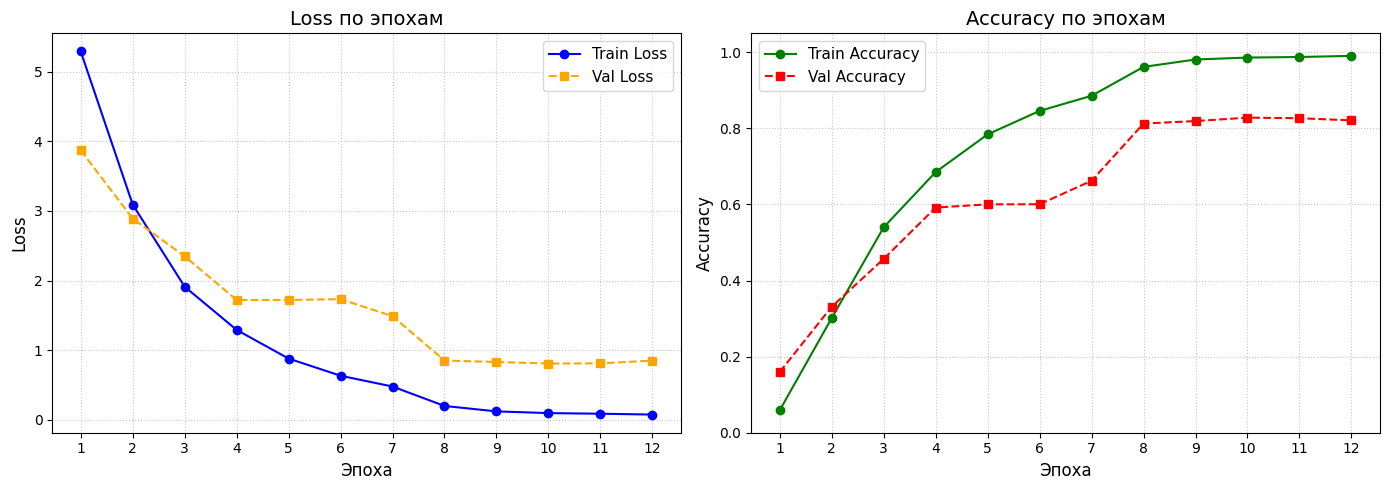

In [ ]:
# Визуализация метрик
plt.figure(figsize=(14, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(range(1, len(ce_train_losses) + 1), ce_train_losses, label='Train Loss', marker='o', linestyle='-', color='blue')
plt.plot(range(1, len(ce_val_losses) + 1), ce_val_losses, label='Val Loss', marker='s', linestyle='--', color='orange')
plt.title('Loss по эпохам', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(range(1, len(ce_train_losses) + 1))

# График точности
plt.subplot(1, 2, 2)
plt.plot(range(1, len(ce_train_accs) + 1), ce_train_accs, label='Train Accuracy', marker='o', linestyle='-', color='green')
plt.plot(range(1, len(ce_val_accs) + 1), ce_val_accs, label='Val Accuracy', marker='s', linestyle='--', color='red')
plt.title('Accuracy по эпохам', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(range(1, len(ce_train_accs) + 1))
plt.ylim(0, 1.05)  # Ограничиваем ось Y для лучшей читаемости


# Отображение графиков
plt.tight_layout()
plt.show()

Можно сказать, что мы достигли здесь выхода на плато и по лоссу и по метрике accuracy. Модель доучилась. По accuracy достигли требуемого минимума, и превысили его на 0,1. Это хороший результат.

### Реализация ArcFace Loss

In [ ]:
import torch.nn.functional as F
import math

In [ ]:
class ResNet50ArcFace(nn.Module):
    def __init__(self, num_classes, s=30.0, m=0.5):
        super().__init__()
        self.resnet = models.resnet50(pretrained=True)
        # Заменяем fc на ArcFace
        self.fc = ArcFace(self.resnet.fc.in_features, num_classes, s, m)

    def forward_features(self, x):
        # Пропускаем через все слои до fc
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)

        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)

        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)
        return x

    def forward(self, x, labels=None):
        features = self.forward_features(x)
        if labels is not None:
            return self.fc(features, labels)  # Для обучения
        else:
            return features  # Для инференса

In [ ]:
class ArcFace(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcFace, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s  # масштаб
        self.m = m  # угол маржи

        # Веса слоя (будут нормализованы при вычислении)
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        # Предварительно вычисляем константы для ускорения
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)  # порог для условия
        self.mm = math.sin(math.pi - m) * m  # коррекция для малых углов

    def forward(self, input, label=None):
        # Нормализация входных признаков
        x = nn.functional.normalize(input)
        # Нормализация весов
        W = nn.functional.normalize(self.weight)
        # Косинусное сходство (базовая матрица сходств)
        cosine = torch.mm(x, W.t())

        # Если мы в режиме инференса ИЛИ label не передан — возвращаем просто масштабированное косинусное сходство
        if not self.training or label is None:
            return cosine * self.s

        # Режим обучения: применяем ArcFace с маржой
        # Вычисление sin(θ) через тождество
        sine = torch.sqrt((1.0 - torch.pow(cosine, 2)).clamp(0, 1))
        # cos(θ + m) = cosθ·cosm − sinθ·sinm
        phi = cosine * self.cos_m - sine * self.sin_m

        # Коррекция для углов > π − m (чтобы градиенты были стабильны)
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        # One-hot для целевых классов
        one_hot = torch.zeros(cosine.size(), device=cosine.device)
        one_hot.scatter_(1, label.view(-1, 1), 1)

        # Для целевого класса используем cos(θ + m), для остальных — cos(θ)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s  # масштабирование

        return output


In [ ]:
model = ResNet50ArcFace(num_classes, s=30.0, m=0.5)

num_classes = len(os.listdir('/content/dataset/train'))
# Заменяем fc на ArcFace
model.fc = ArcFace(model.fc.in_features, num_classes, s=30.0, m=0.5)

model.to(device)

ResNet50ArcFace(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

In [ ]:
criterion = nn.CrossEntropyLoss()  # ArcFace сам добавляет softmax
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in tqdm(loader, desc="Train"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # Получаем признаки перед fc (для этого я добавила метод в модель)
        features = model.forward_features(inputs)
        # ArcFace forward — передаём признаки и метки
        outputs = model.fc(features, labels)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total



def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Val"):
            inputs, labels = inputs.to(device), labels.to(device)

            # Получаем признаки
            features = model.forward_features(inputs)
            # ArcFace forward
            outputs = model.fc(features, labels)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()


    return running_loss / total, correct / total

In [ ]:
arc_train_losses, arc_val_losses = [], []
arc_train_accs, arc_val_accs = [], []

for epoch in range(15):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = val_epoch(model, val_loader, criterion, device)
    scheduler.step()

    arc_train_losses.append(train_loss)
    arc_val_losses.append(val_loss)
    arc_train_accs.append(train_acc)
    arc_val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")



torch.save(model.state_dict(), "resnet_arcface.pth")
print("Модель сохранена как 'resnet_arcface.pth'")

Val: 100%|██████████| 105/105 [00:12<00:00,  8.58it/s]


Epoch 1: Train Loss: 19.5778, Acc: 0.0000 Val Loss: 3.8736, Acc: 0.1989


Val: 100%|██████████| 105/105 [00:11<00:00,  9.08it/s]


Epoch 2: Train Loss: 17.2942, Acc: 0.0000 Val Loss: 3.2234, Acc: 0.2954


Val: 100%|██████████| 105/105 [00:12<00:00,  8.67it/s]


...

Epoch 13: Train Loss: 4.3796, Acc: 0.5485 Val Loss: 0.9720, Acc: 0.8140


Val: 100%|██████████| 105/105 [00:12<00:00,  8.74it/s]


Epoch 14: Train Loss: 4.0044, Acc: 0.5841 Val Loss: 0.8848, Acc: 0.8307


Val: 100%|██████████| 105/105 [00:12<00:00,  8.67it/s]


Epoch 15: Train Loss: 3.4609, Acc: 0.6357 Val Loss: 0.9284, Acc: 0.8241
Модель сохранена как 'resnet_arcface.pth'


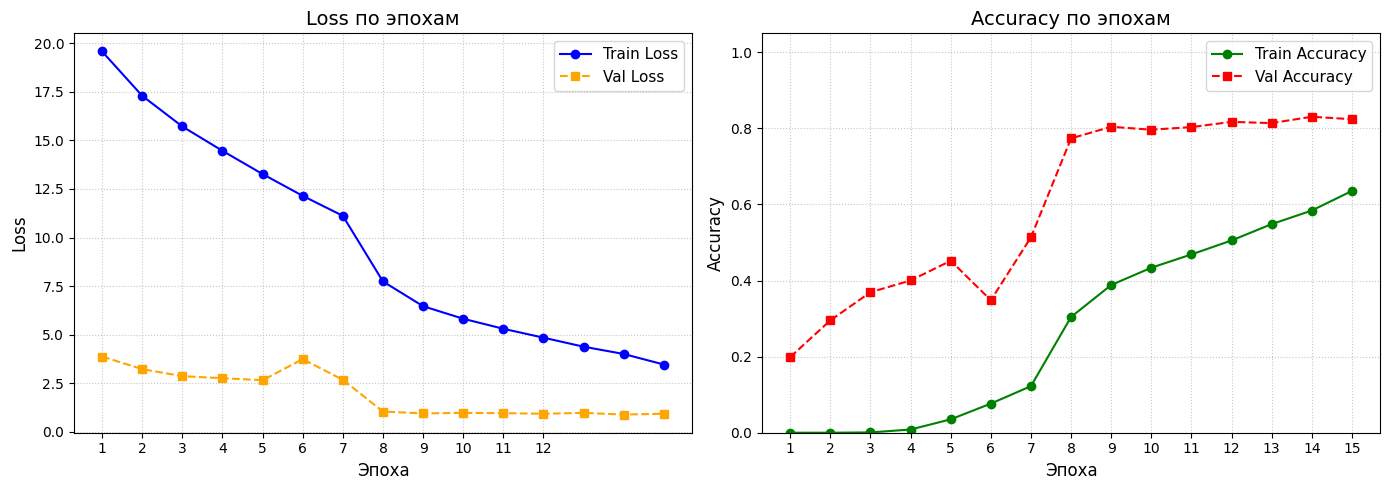

In [ ]:
# Визуализация метрик
plt.figure(figsize=(14, 5))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(range(1, len(arc_train_losses) + 1), arc_train_losses, label='Train Loss', marker='o', linestyle='-', color='blue')
plt.plot(range(1, len(arc_val_losses) + 1), arc_val_losses, label='Val Loss', marker='s', linestyle='--', color='orange')
plt.title('Loss по эпохам', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(range(1, len(ce_train_losses) + 1))

# График точности
plt.subplot(1, 2, 2)
plt.plot(range(1, len(arc_train_accs) + 1), arc_train_accs, label='Train Accuracy', marker='o', linestyle='-', color='green')
plt.plot(range(1, len(arc_val_accs) + 1), arc_val_accs, label='Val Accuracy', marker='s', linestyle='--', color='red')
plt.title('Accuracy по эпохам', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(range(1, len(arc_train_accs) + 1))
plt.ylim(0, 1.05)  # Ограничиваем ось Y для лучшей читаемости


# Отображение графиков
plt.tight_layout()
plt.show()

In [ ]:
model_ce_path = '/content/resnet_ce.pth'
model_arcface_path = '/content/resnet_arcface.pth'

# Целевые пути
drive_ce_path = '/content/drive/MyDrive/DLS1/resnet_ce.pth'
drive_arcface_path = '/content/drive/MyDrive/DLS1/resnet_arcface.pth'


# Копируем файлы
!cp "{model_ce_path}" "{drive_ce_path}"
!cp "{model_arcface_path}" "{drive_arcface_path}"

# Список файлов в корне Drive
!ls "/content/drive/MyDrive/DLS1/"

aligned_images	    person_id_aligned.csv  resnet_ce.pth
aligned_images.zip  resnet_arcface.pth


Теперь переходим к реализации Пайплайна, ляляляля:)